# CS 198/199 
# Joaquin B. Salvador
# Explainable AI for Post-COVID Psychological Profile Prediction

## 1.0
### Initial data exploration

We currently have a dataset from an online survey conducted on the Japanese population when the number of COVID-19-positive cases was high and when the COVID-19 pandemic was officially declared to be over. The dataset has 92 attributes, including socio-demographic, COVID-19-related, mental health, and coping behavior information from 2,659 respondents.

In [1]:
# -------------------------------------
# Library configuration
# -------------------------------------

# Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.max_rows = 1000
df1 = pd.read_csv('..\\data\\interim\\dataset_1st-5th.csv', low_memory=False)
df2 = pd.read_csv('..\\data\\interim\\dataset_1st-6th.csv', low_memory=False)

In [3]:
df1

,SAMPLEID,K6_total,PHQ9_total,GAD7_total,SSS8_total,PTGI-X,SHS_total,UCLA_total,LSNS6_total,AUDIT
0,1106,3.0,10.0,4.0,11.0,8.0,3.50,29.0,1.0,0.0
1,1759,3.0,1.0,1.0,0.0,20.0,3.75,22.0,12.0,5.0
2,1916,6.0,1.0,3.0,6.0,4.0,2.50,24.0,5.0,14.0
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,4.0,5.0,4.0,13.0,0.0,1.50,40.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...
24045,30063086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24046,30081779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24047,30093317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24048,30094439,6.0,9.0,0.0,9.0,12.0,5.50,32.0,2.0,0.0


In [4]:
df2

,SAMPLEID,K6_total,PHQ9_total,GAD7_total,SSS8_total,PTGI-X,SHS_total,UCLA_total,LSNS6_total,AUDIT
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,12.0,15.0,14.0,18.0,19.0,4.0,24.0,4.0,6.0
...,...,...,...,...,...,...,...,...,...,...
24045,30063086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24046,30081779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24047,30093317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24048,30094439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df1_sorted = df1.sort_values(by=['SAMPLEID'])
df2_sorted = df2.sort_values(by=['SAMPLEID'])

In [6]:
df1_cleaned = df1_sorted.dropna()
df2_cleaned = df2_sorted.dropna()

In [7]:
df1_cleaned.set_index('SAMPLEID', inplace=True)
df2_cleaned.set_index('SAMPLEID', inplace=True)

In [8]:
merged_df = df1_cleaned.merge(df2_cleaned, on="SAMPLEID", suffixes=('_old', '_new'))
merged_df

,K6_total_old,PHQ9_total_old,GAD7_total_old,SSS8_total_old,PTGI-X_old,SHS_total_old,UCLA_total_old,LSNS6_total_old,AUDIT_old,K6_total_new,PHQ9_total_new,GAD7_total_new,SSS8_total_new,PTGI-X_new,SHS_total_new,UCLA_total_new,LSNS6_total_new,AUDIT_new
SAMPLEID,,,,,,,,,,,,,,,,,,
3793,4.0,5.0,4.0,13.0,0.0,1.50,40.0,4.0,4.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
9703,0.0,0.0,0.0,1.0,7.0,4.00,10.0,17.0,0.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11532,24.0,0.0,0.0,4.0,0.0,4.50,31.0,4.0,0.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15778,0.0,0.0,0.0,0.0,13.0,5.25,16.0,15.0,0.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
18713,0.0,0.0,0.0,0.0,18.0,5.00,23.0,5.0,0.0,0.0,2.0,0.0,0.0,15.0,5.25,22.0,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26475923,3.0,1.0,15.0,26.0,21.0,4.25,25.0,6.0,2.0,12.0,4.0,7.0,13.0,18.0,4.00,25.0,6.0,6.0
26476814,13.0,15.0,11.0,16.0,18.0,4.50,24.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.00,25.0,0.0,0.0
26476898,14.0,7.0,7.0,8.0,14.0,4.00,24.0,0.0,0.0,13.0,6.0,0.0,5.0,12.0,3.75,26.0,4.0,0.0


In [9]:
column_names = df1_cleaned.columns.tolist()
column_names

['K6_total',
 'PHQ9_total',
 'GAD7_total',
 'SSS8_total',
 'PTGI-X',
 'SHS_total',
 'UCLA_total',
 'LSNS6_total',
 'AUDIT']

In [10]:
for col in column_names:
    merged_df[col + '_diff'] = merged_df[col + '_new'] - merged_df[col + '_old']
    
merged_df

,K6_total_old,PHQ9_total_old,GAD7_total_old,SSS8_total_old,PTGI-X_old,SHS_total_old,UCLA_total_old,LSNS6_total_old,AUDIT_old,K6_total_new,...,AUDIT_new,K6_total_diff,PHQ9_total_diff,GAD7_total_diff,SSS8_total_diff,PTGI-X_diff,SHS_total_diff,UCLA_total_diff,LSNS6_total_diff,AUDIT_diff
SAMPLEID,,,,,,,,,,,,,,,,,,,,,
3793,4.0,5.0,4.0,13.0,0.0,1.50,40.0,4.0,4.0,12.0,...,6.0,8.0,10.0,10.0,5.0,19.0,2.50,-16.0,0.0,2.0
9703,0.0,0.0,0.0,1.0,7.0,4.00,10.0,17.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,-4.0,0.50,1.0,1.0,0.0
11532,24.0,0.0,0.0,4.0,0.0,4.50,31.0,4.0,0.0,1.0,...,0.0,-23.0,2.0,0.0,-3.0,0.0,-0.50,1.0,-4.0,0.0
15778,0.0,0.0,0.0,0.0,13.0,5.25,16.0,15.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.25,5.0,-2.0,0.0
18713,0.0,0.0,0.0,0.0,18.0,5.00,23.0,5.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,-3.0,0.25,-1.0,13.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26475923,3.0,1.0,15.0,26.0,21.0,4.25,25.0,6.0,2.0,12.0,...,6.0,9.0,3.0,-8.0,-13.0,-3.0,-0.25,0.0,0.0,4.0
26476814,13.0,15.0,11.0,16.0,18.0,4.50,24.0,0.0,1.0,0.0,...,0.0,-13.0,-15.0,-11.0,-16.0,-18.0,-0.50,1.0,0.0,-1.0
26476898,14.0,7.0,7.0,8.0,14.0,4.00,24.0,0.0,0.0,13.0,...,0.0,-1.0,-1.0,-7.0,-3.0,-2.0,-0.25,2.0,4.0,0.0


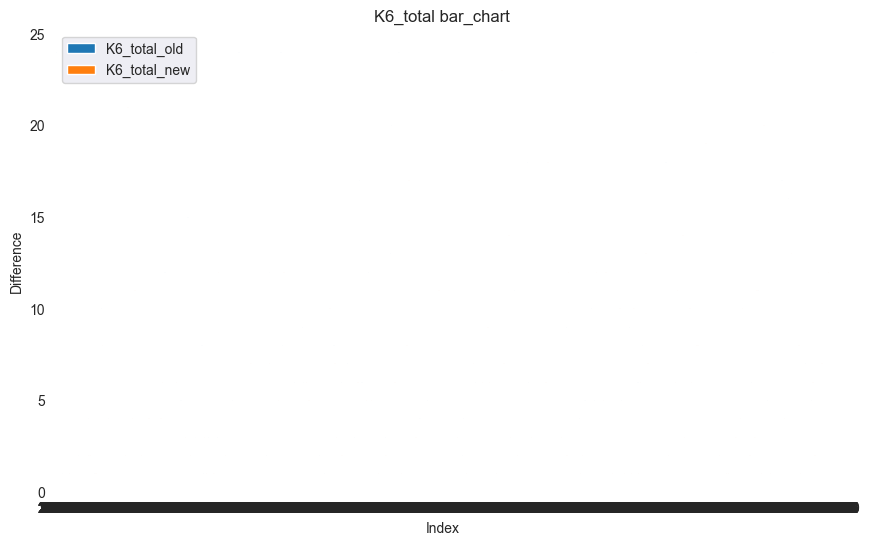

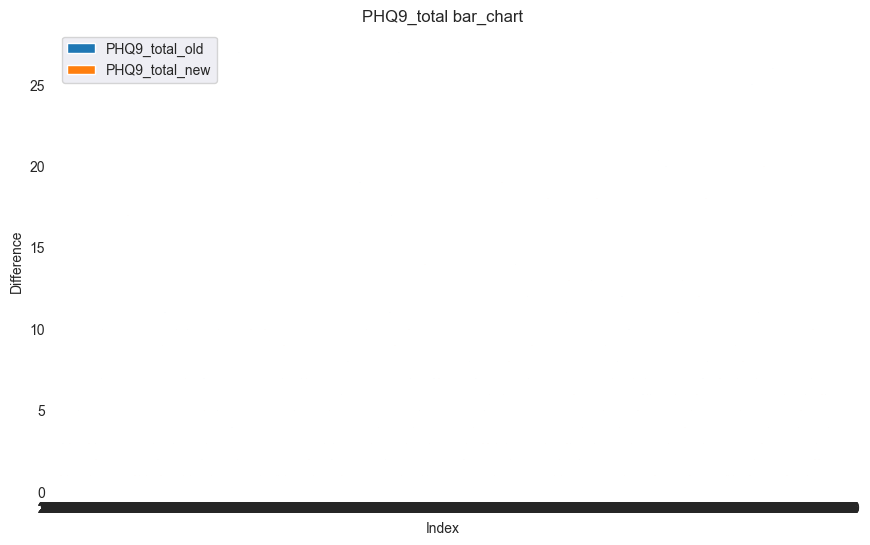

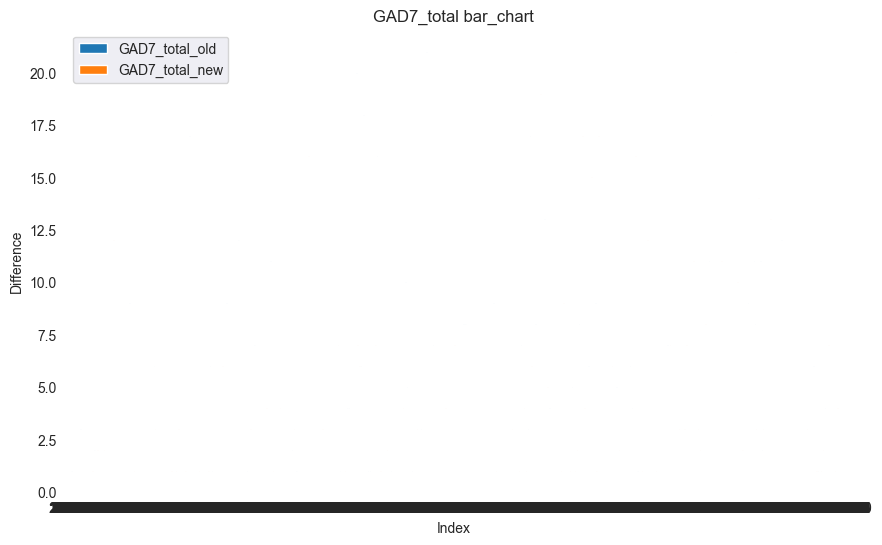

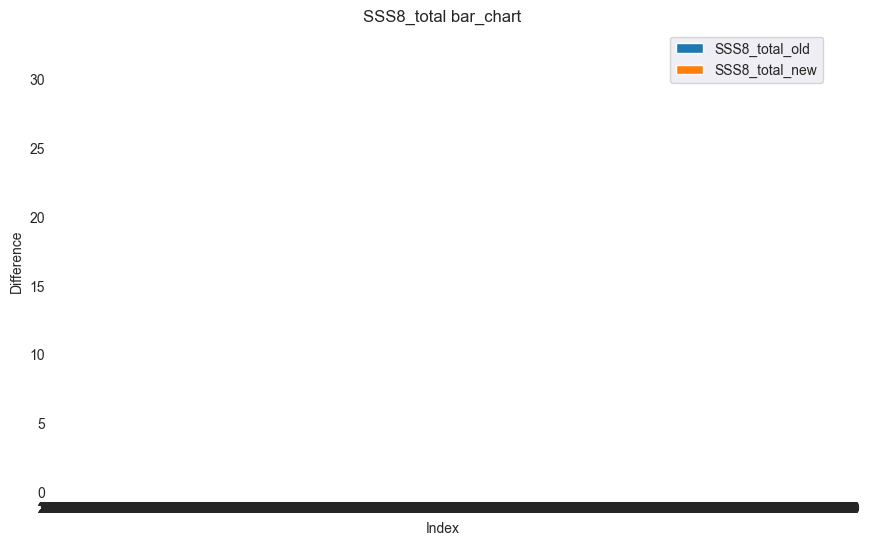

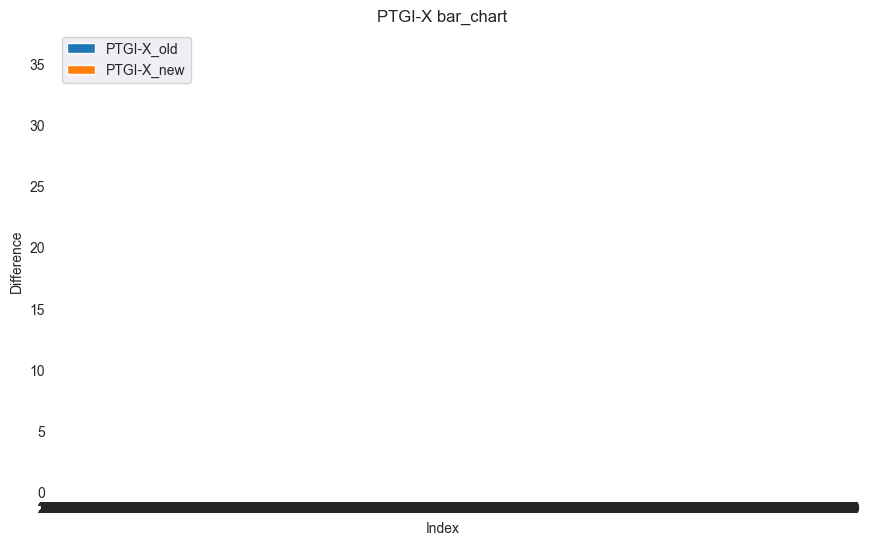

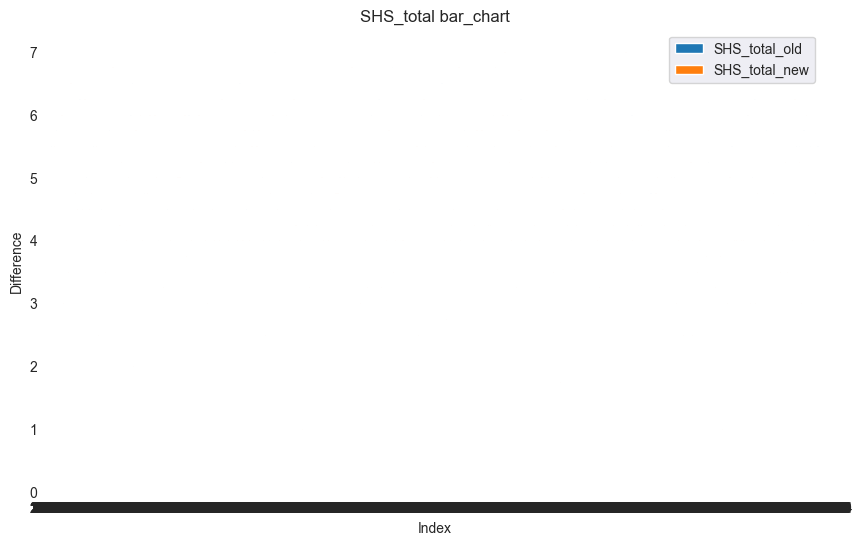

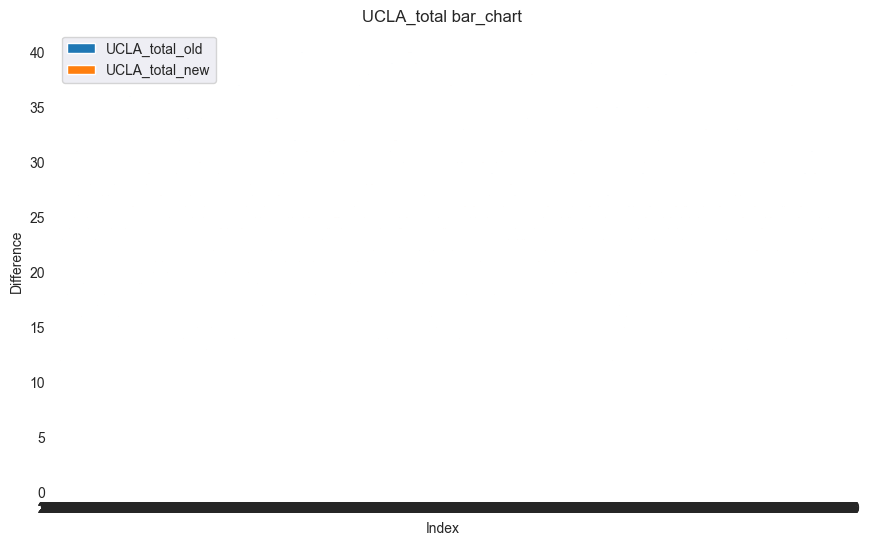

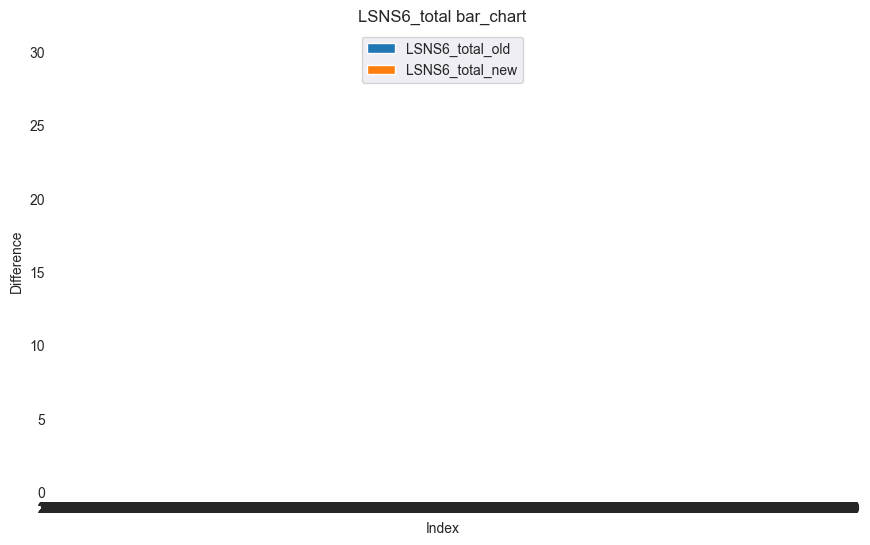

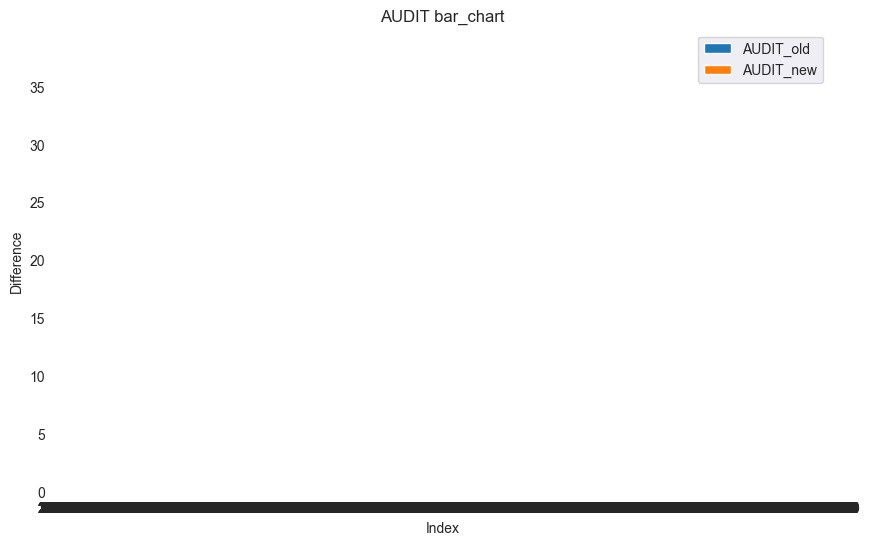

In [11]:
# Bar Chart
graph_type = 'bar_chart'
    
for col in column_names:
    col_old = col + '_old'
    col_new = col + '_new'
    
    merged_df[[col_old, col_new]].plot(kind='bar', figsize=(10, 6))

    plt.title(col + ' ' + graph_type)
    plt.ylabel('Difference')
    plt.xlabel('Index')
    plt.xticks(rotation=0)
    
    plt.show()
    plt.close()

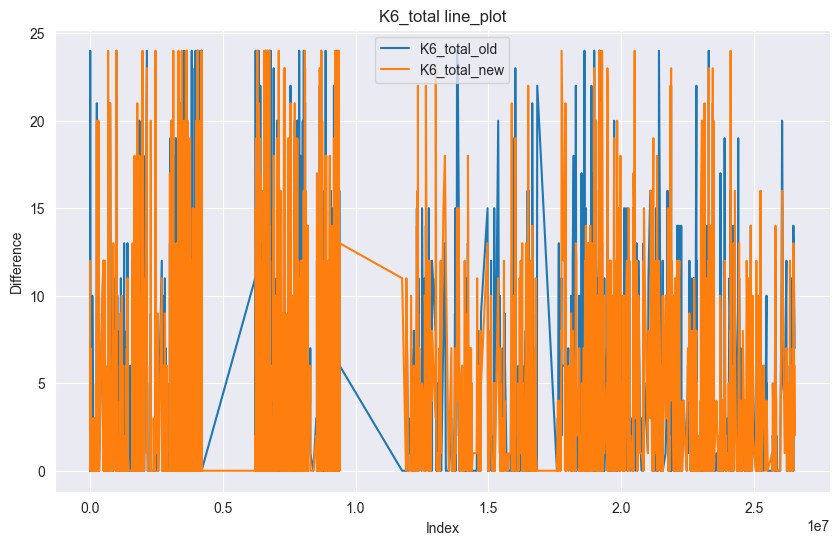

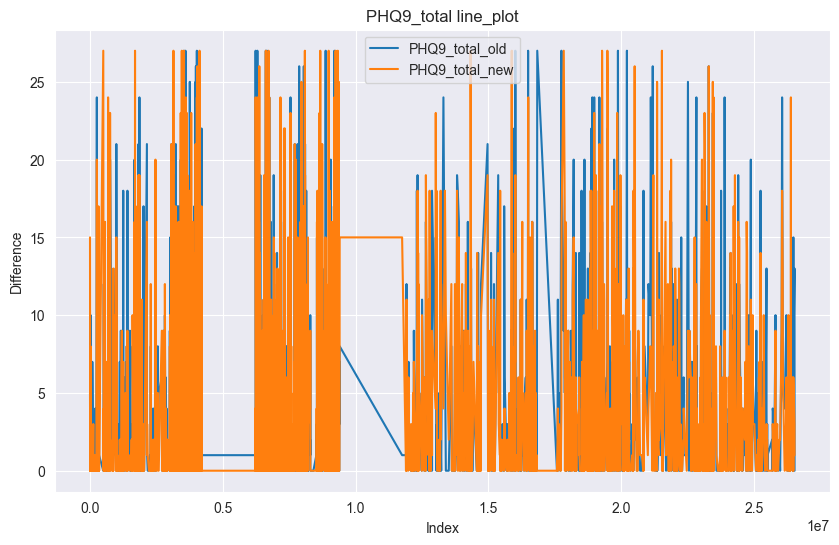

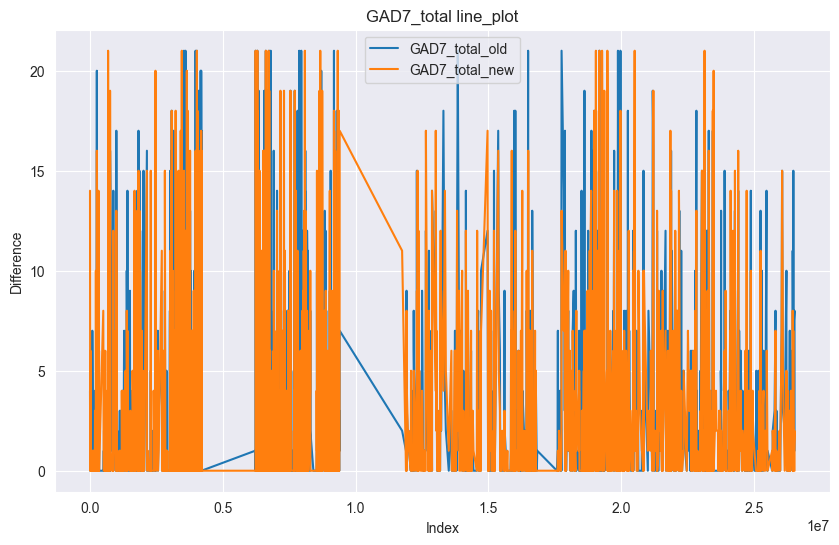

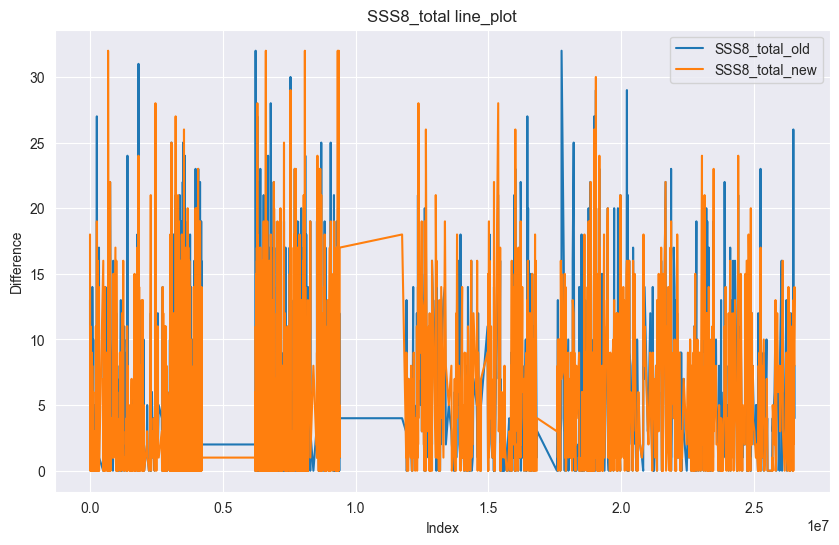

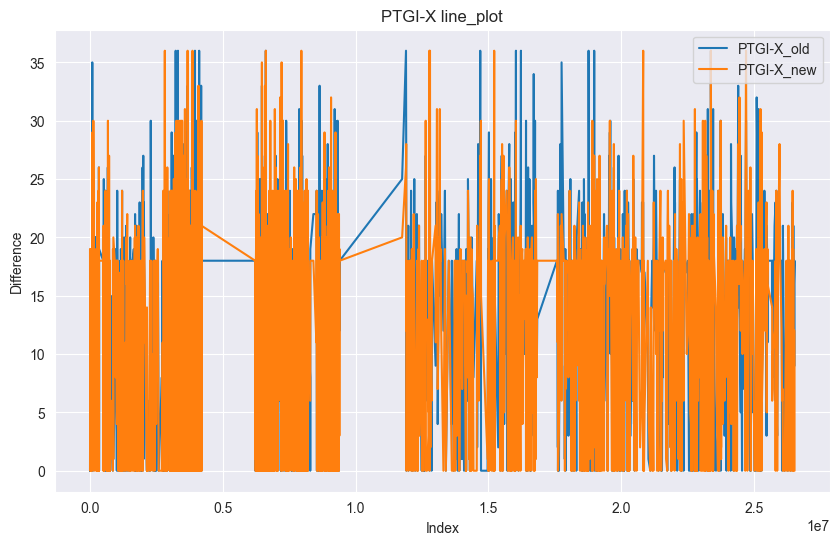

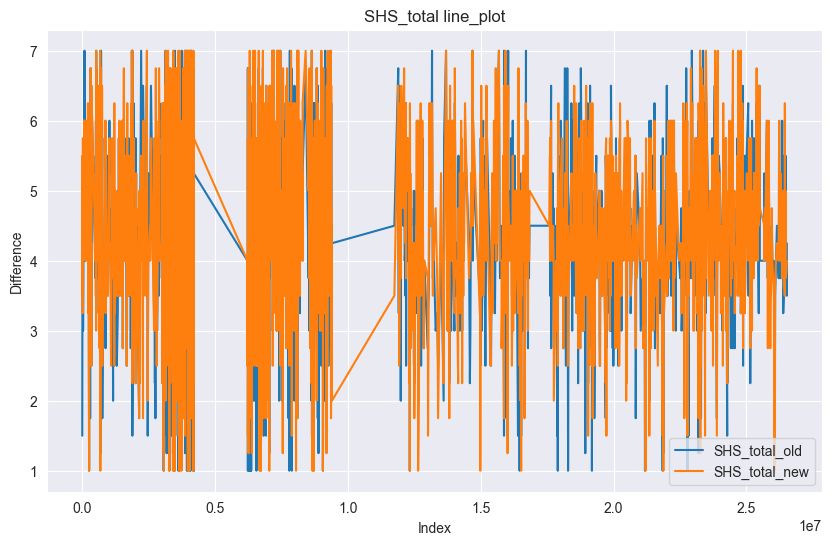

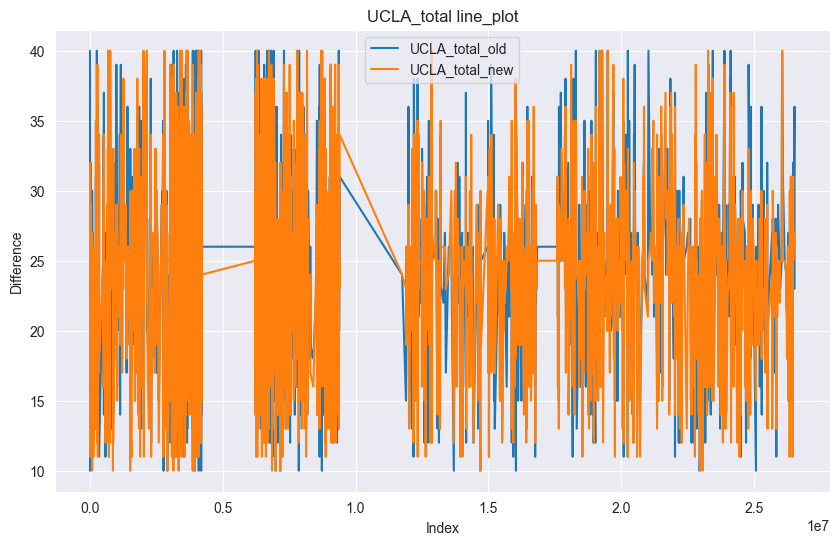

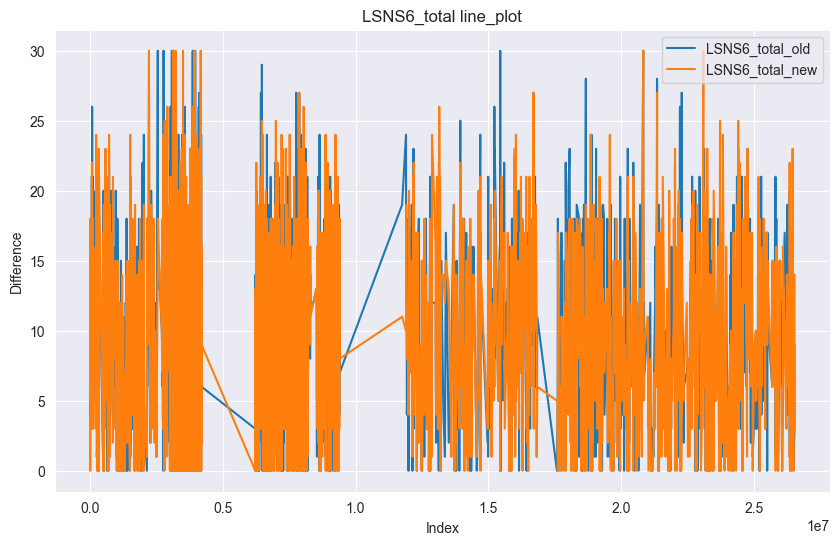

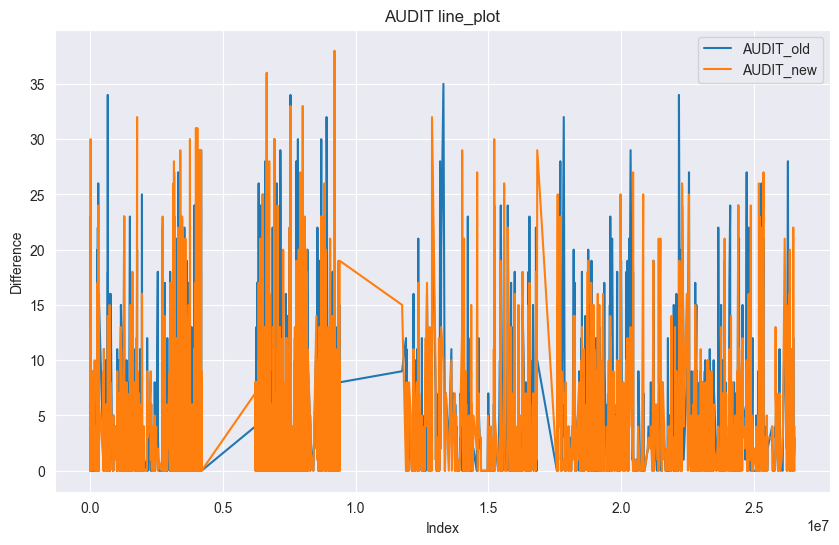

In [12]:
# Line plot
graph_type = 'line_plot'

for col in column_names:
    col_old = col + '_old'
    col_new = col + '_new'
    
    merged_df[[col_old, col_new]].plot(kind='line', figsize=(10, 6))

    plt.title(col + ' ' + graph_type)
    plt.ylabel('Difference')
    plt.xlabel('Index')
    plt.grid(True)
    
    plt.show()
    plt.close()

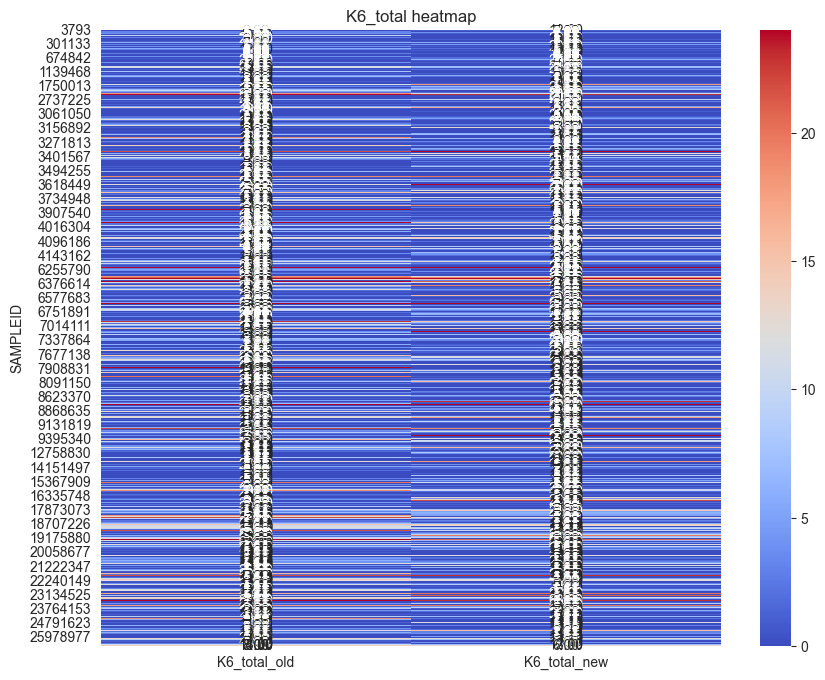

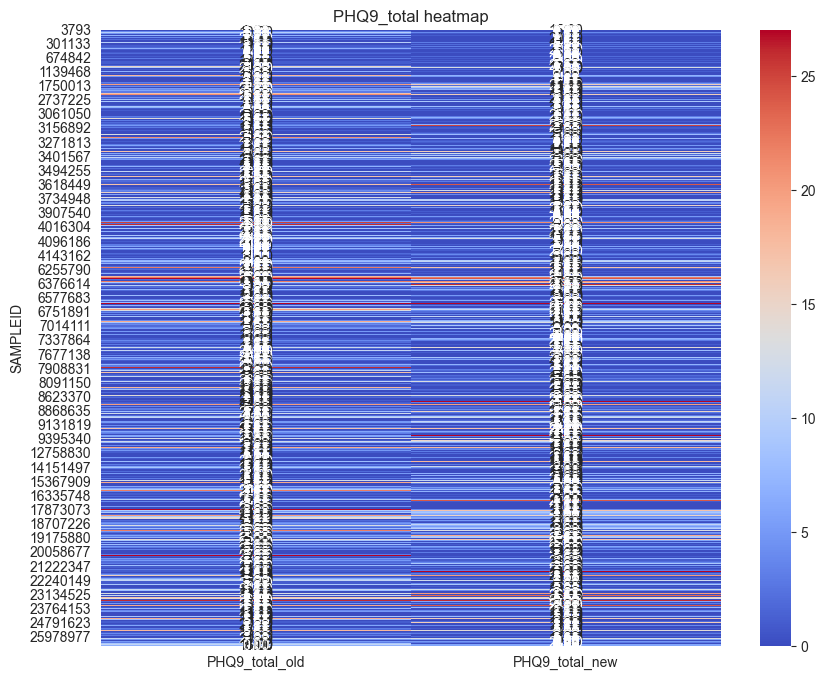

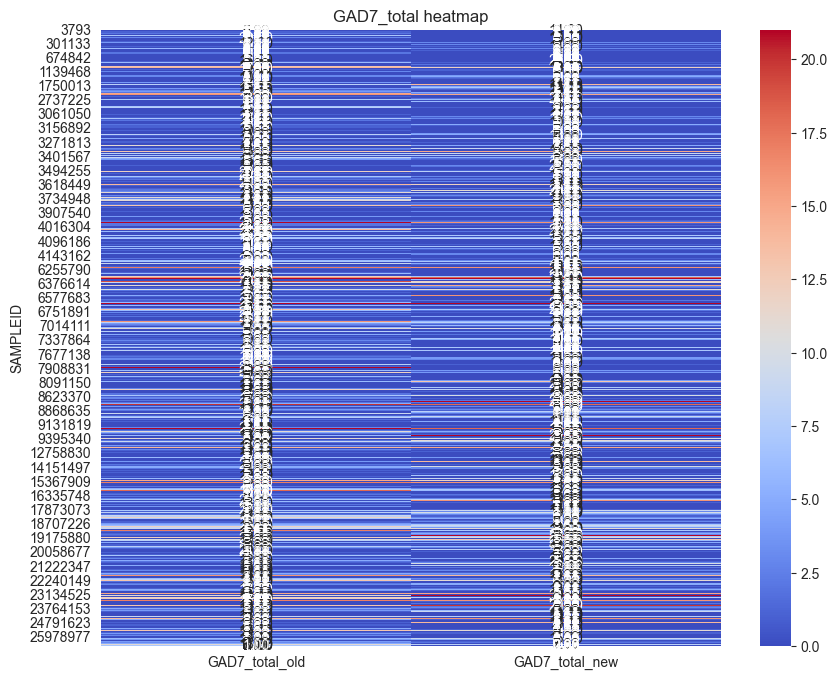

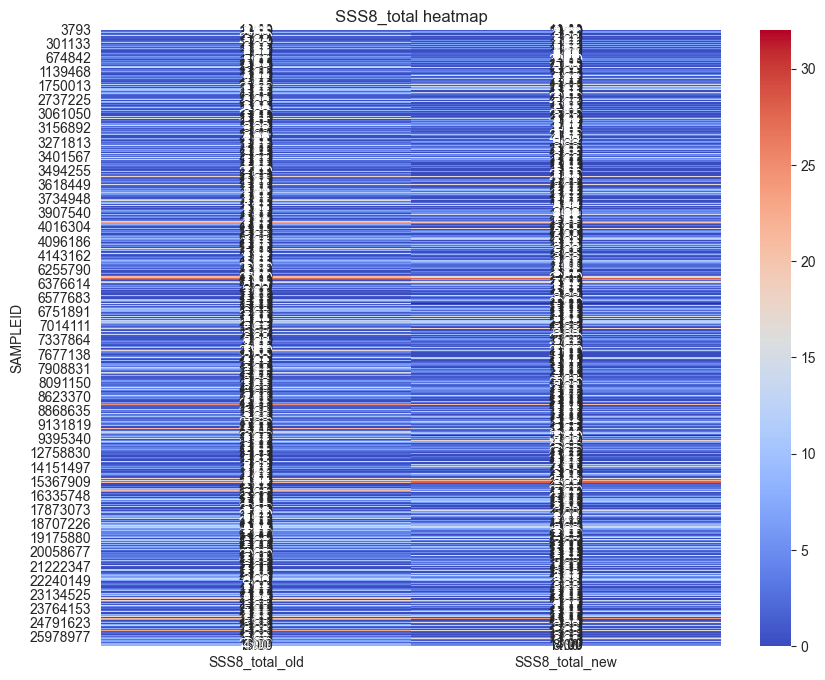

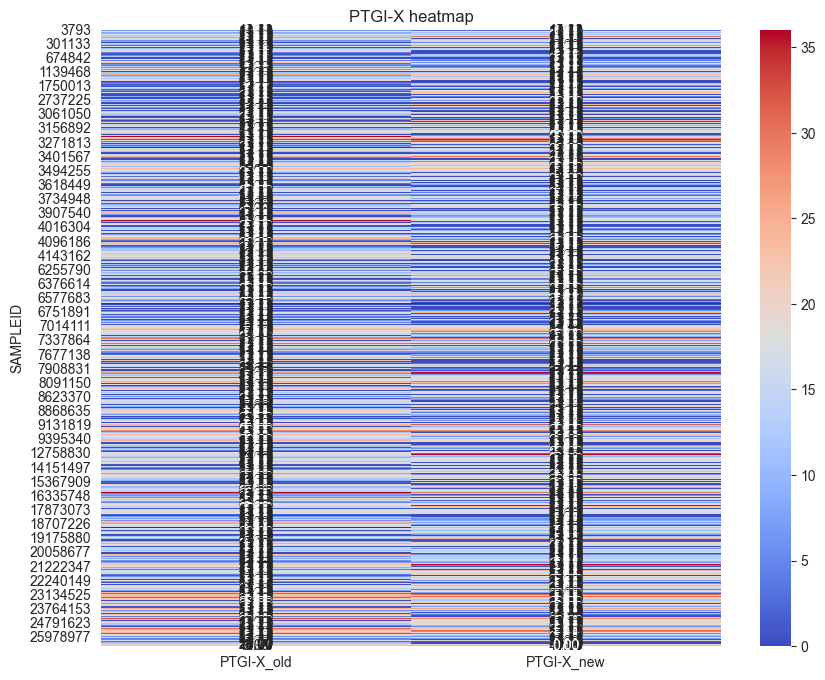

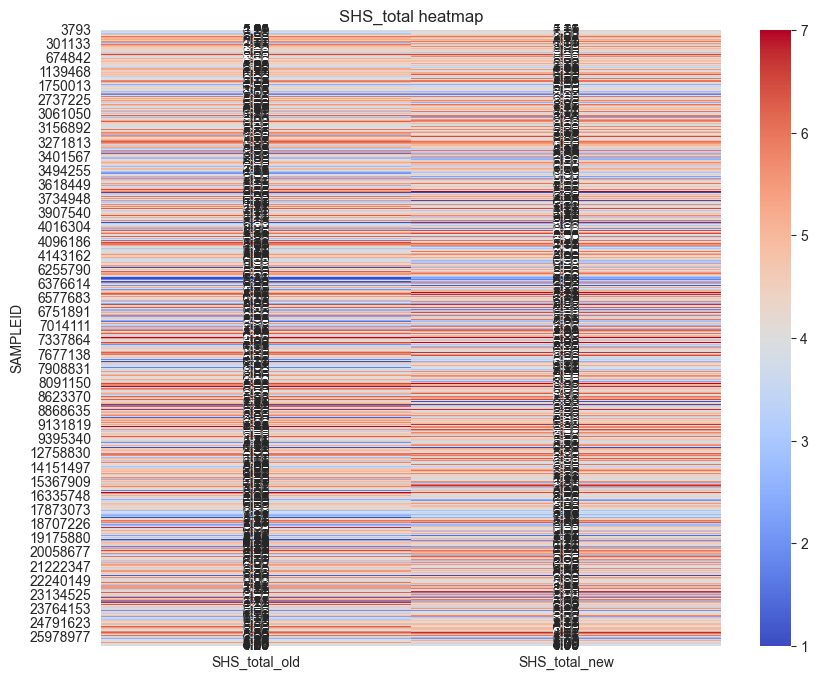

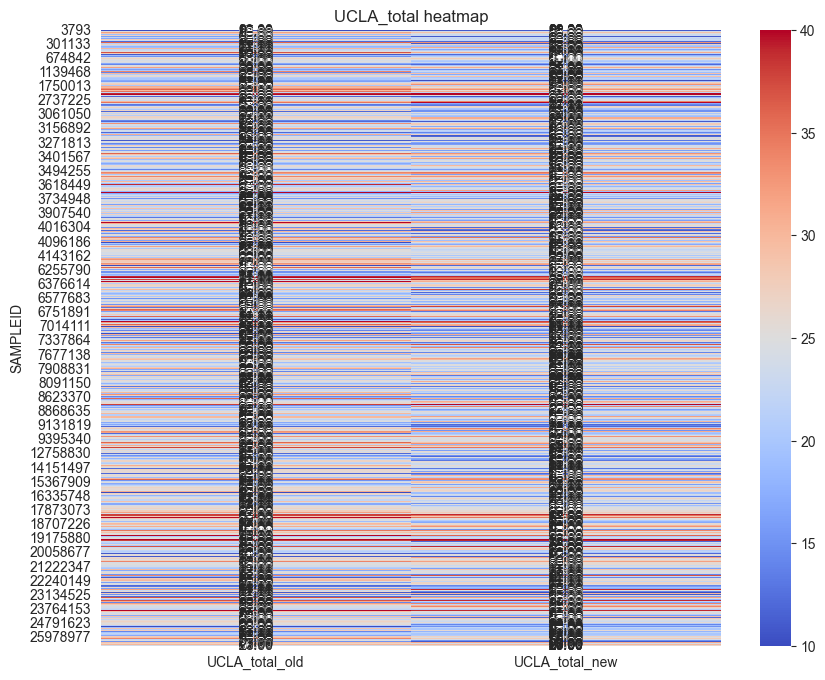

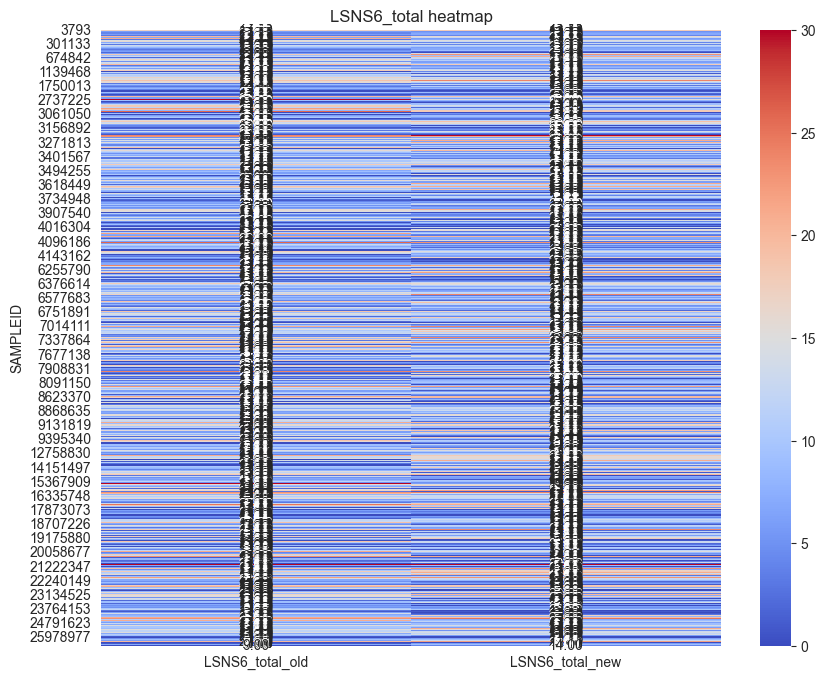

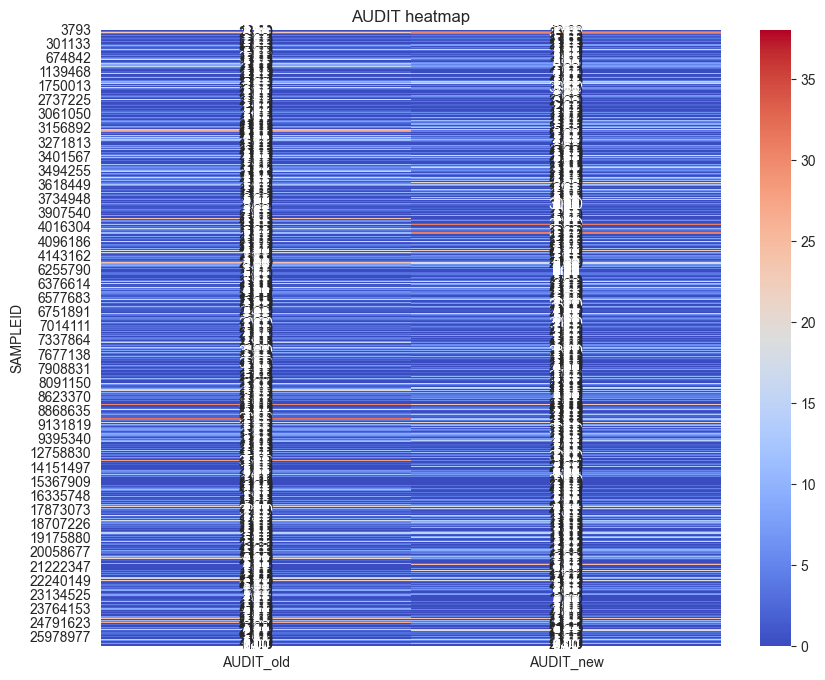

In [13]:
# Heatmap
graph_type = 'heatmap'

for col in column_names:
    col_old = col + '_old'
    col_new = col + '_new'
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(merged_df[[col_old, col_new]], cmap='coolwarm', annot=True, fmt='.2f')

    plt.title(col + ' ' + graph_type)
    
    plt.show()
    plt.close()

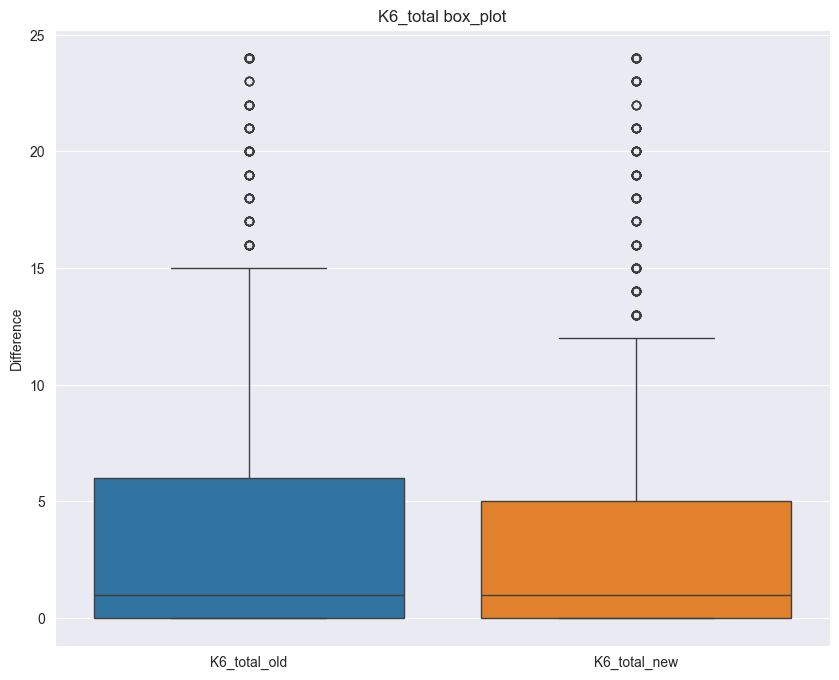

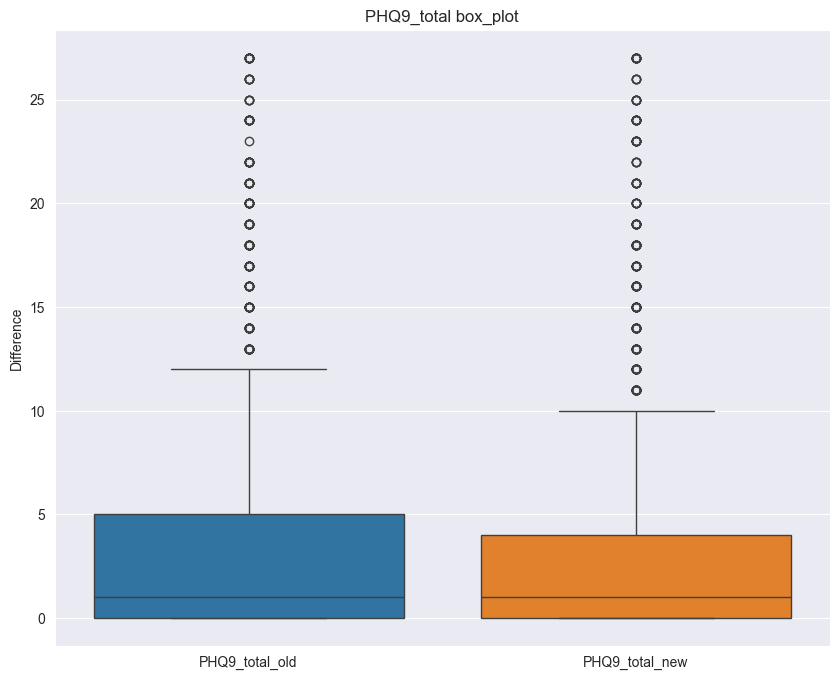

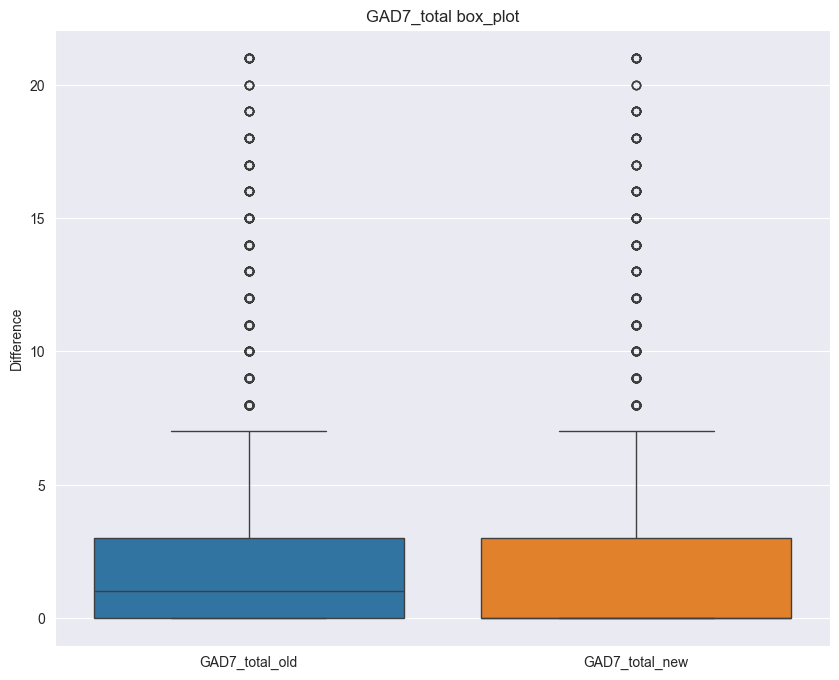

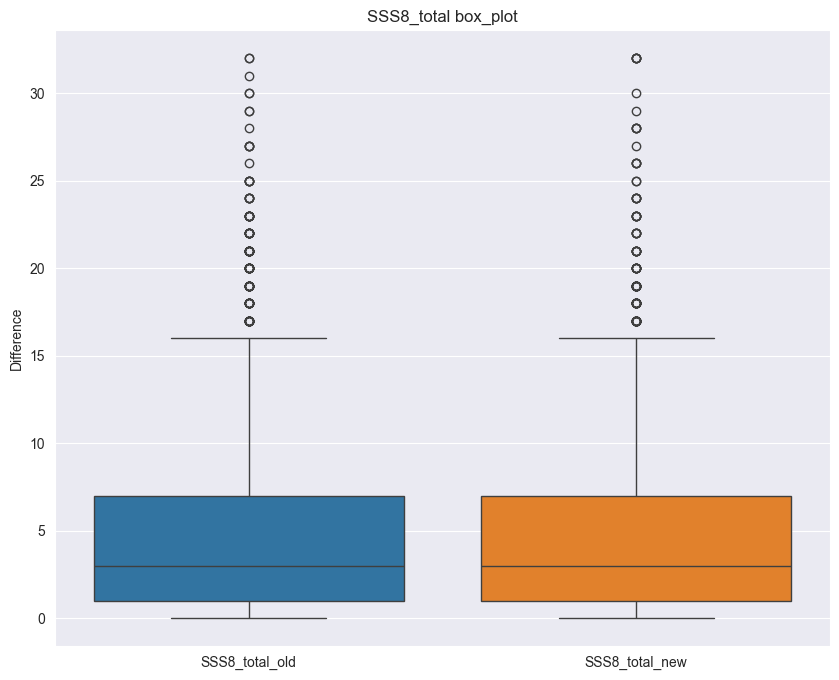

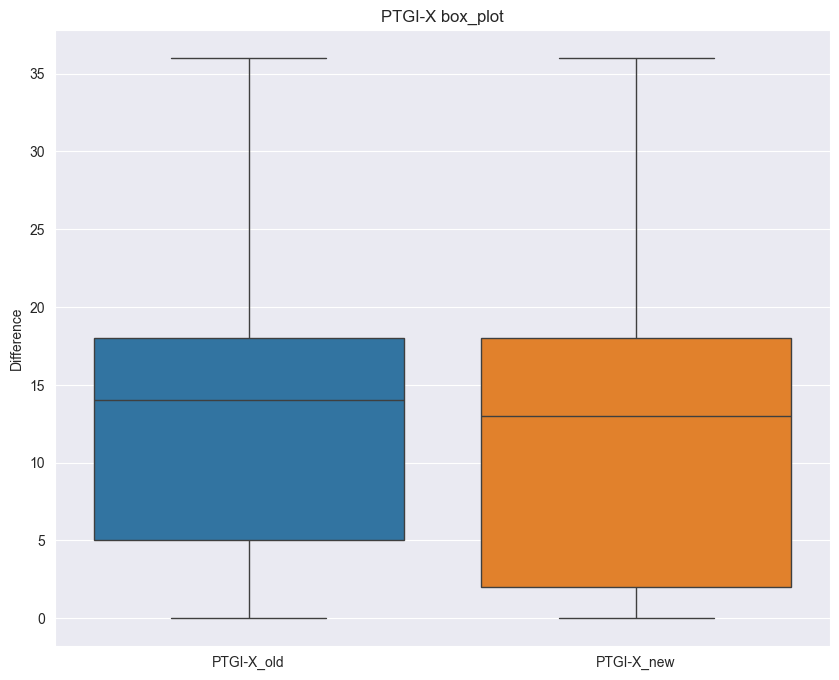

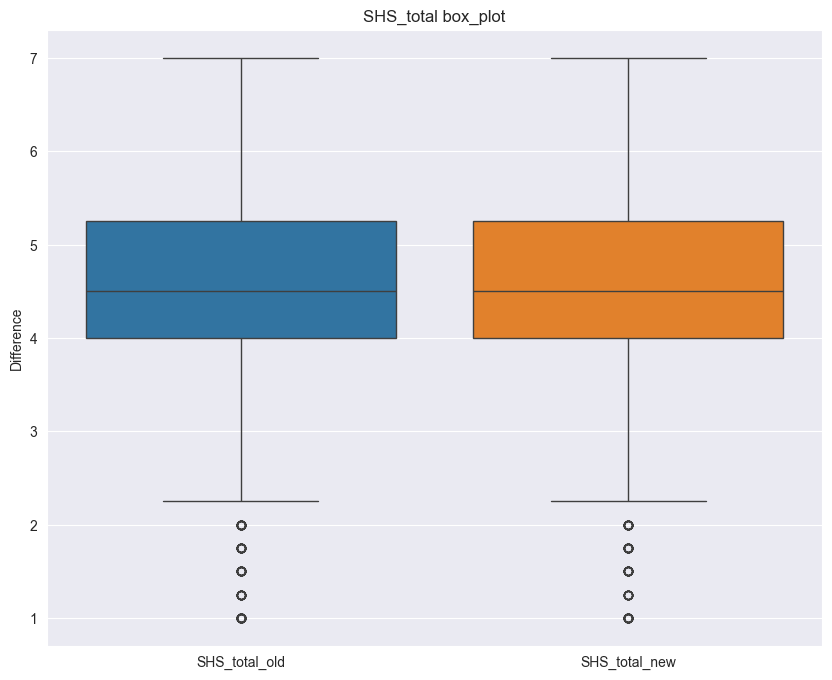

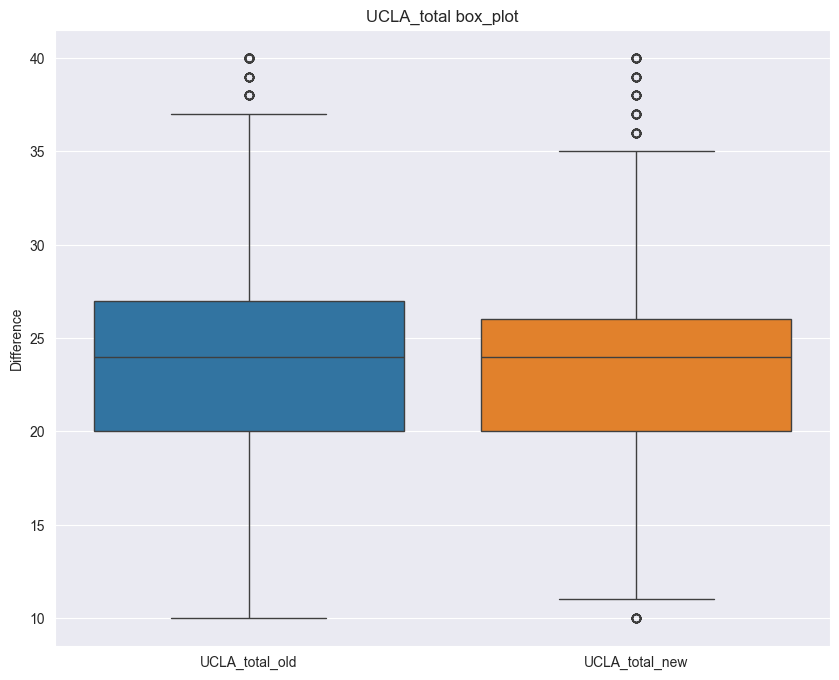

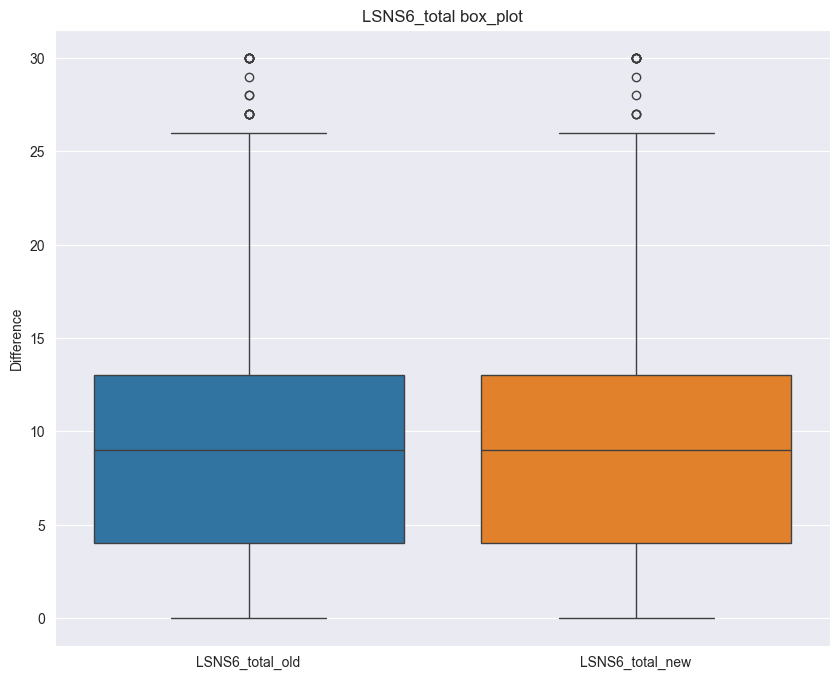

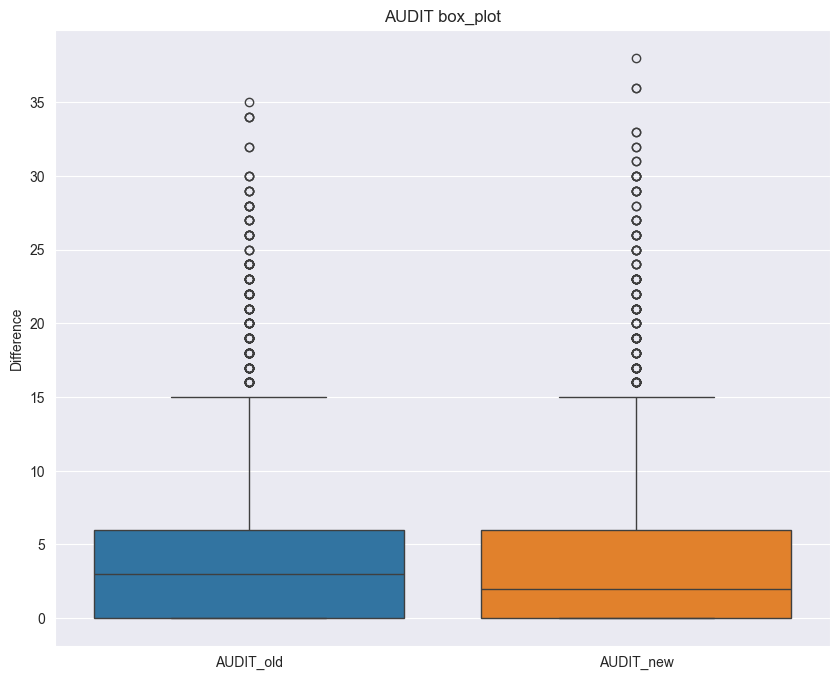

In [14]:
# Box Plot
graph_type = 'box_plot'

for col in column_names:
    col_old = col + '_old'
    col_new = col + '_new'
    
    plt.figure(figsize=(10, 8))
    sns.boxplot(data=merged_df[[col_old, col_new]])

    plt.title(col + ' ' + graph_type)
    plt.ylabel('Difference')
    
    plt.show()
    plt.close()

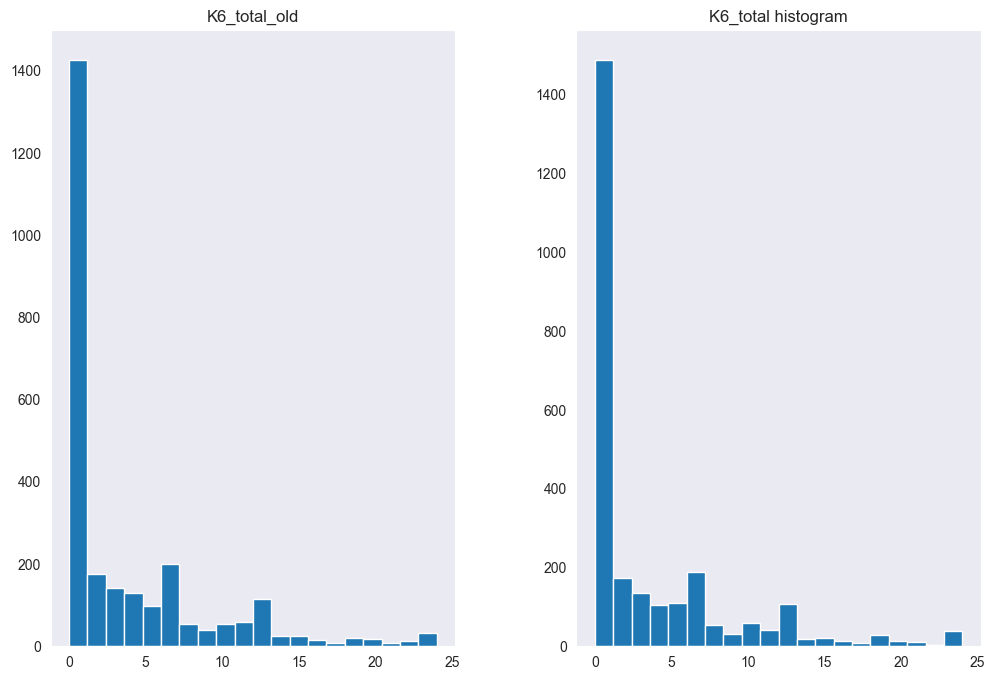

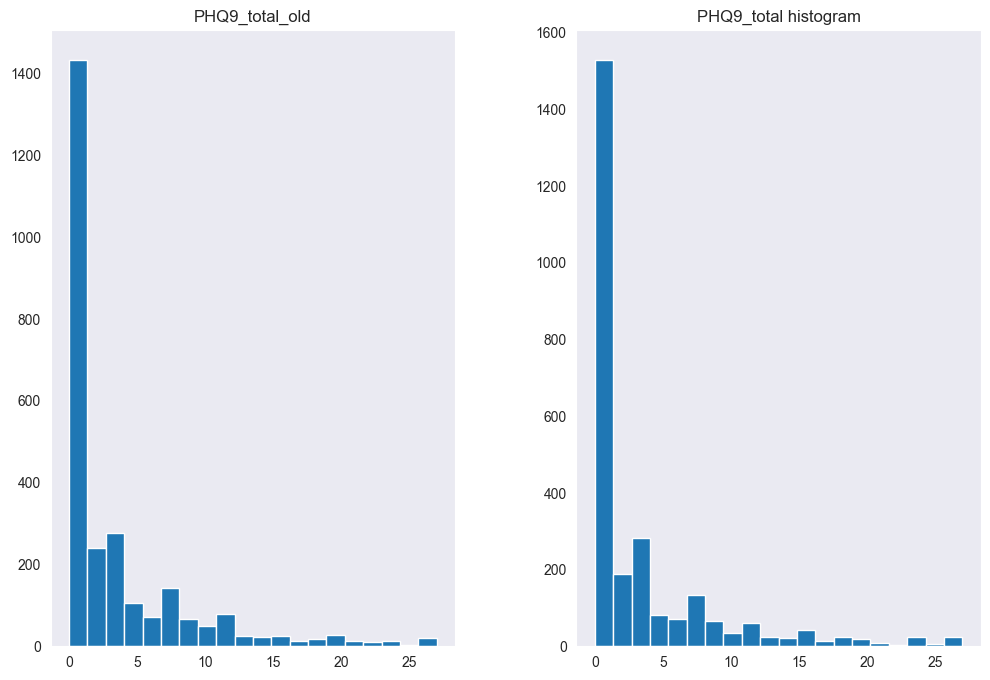

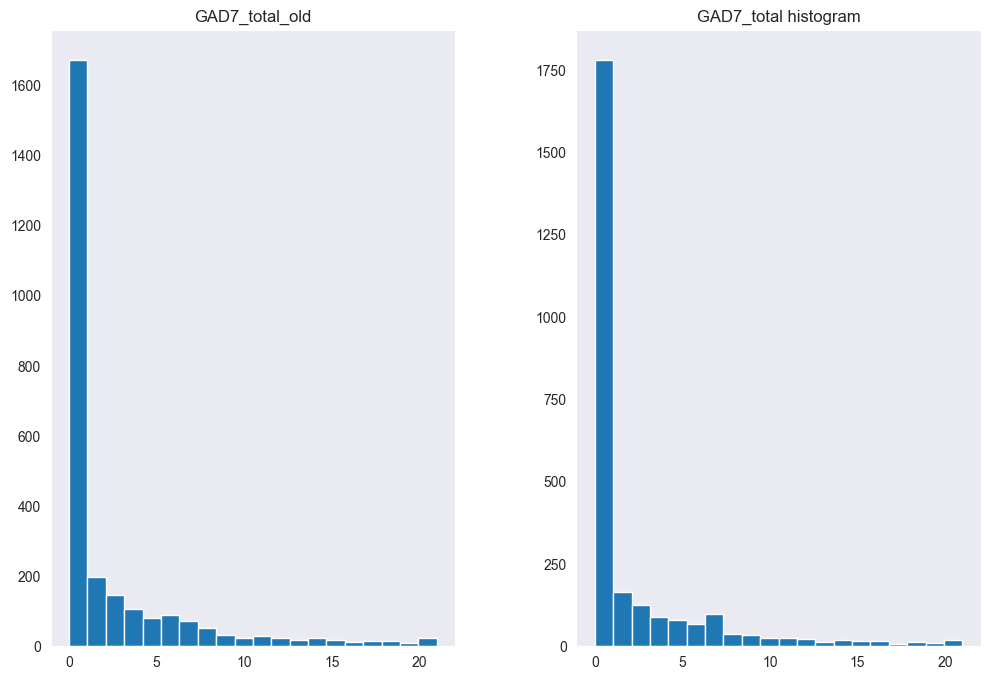

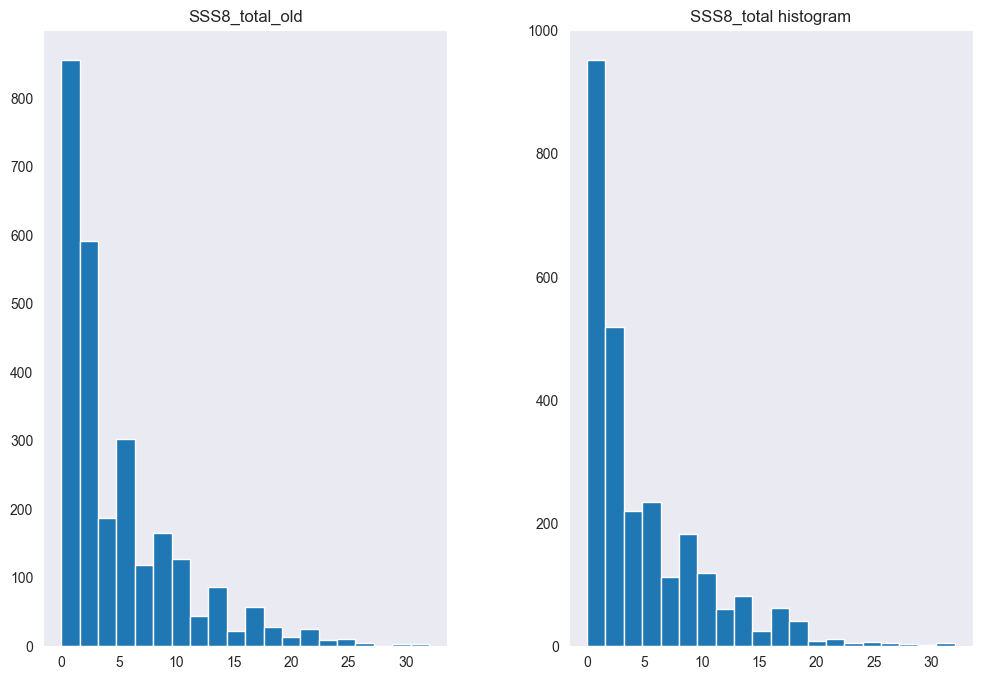

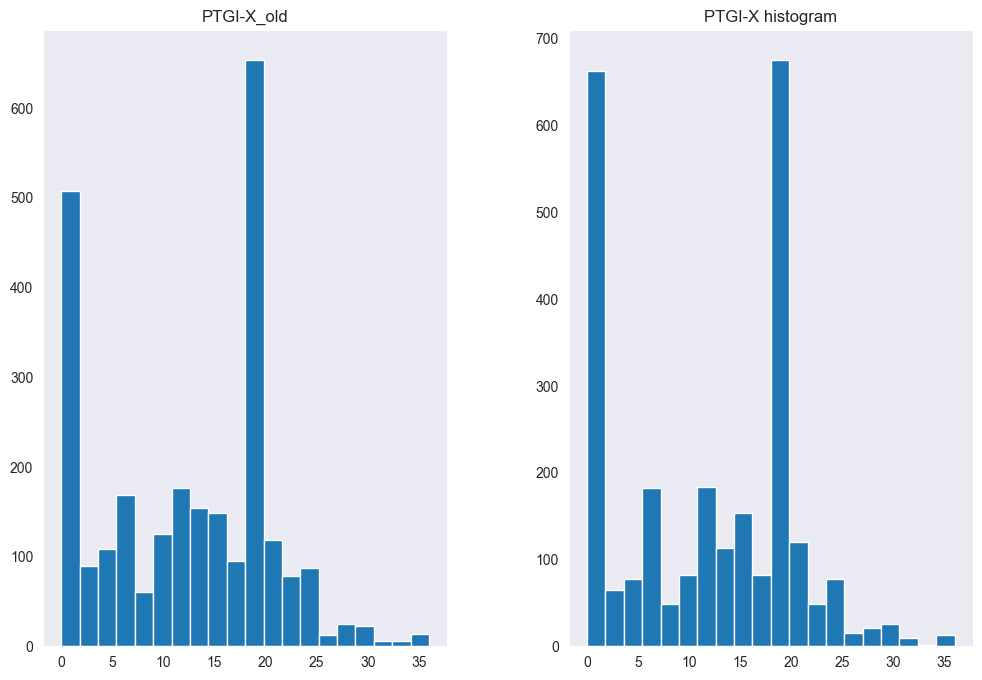

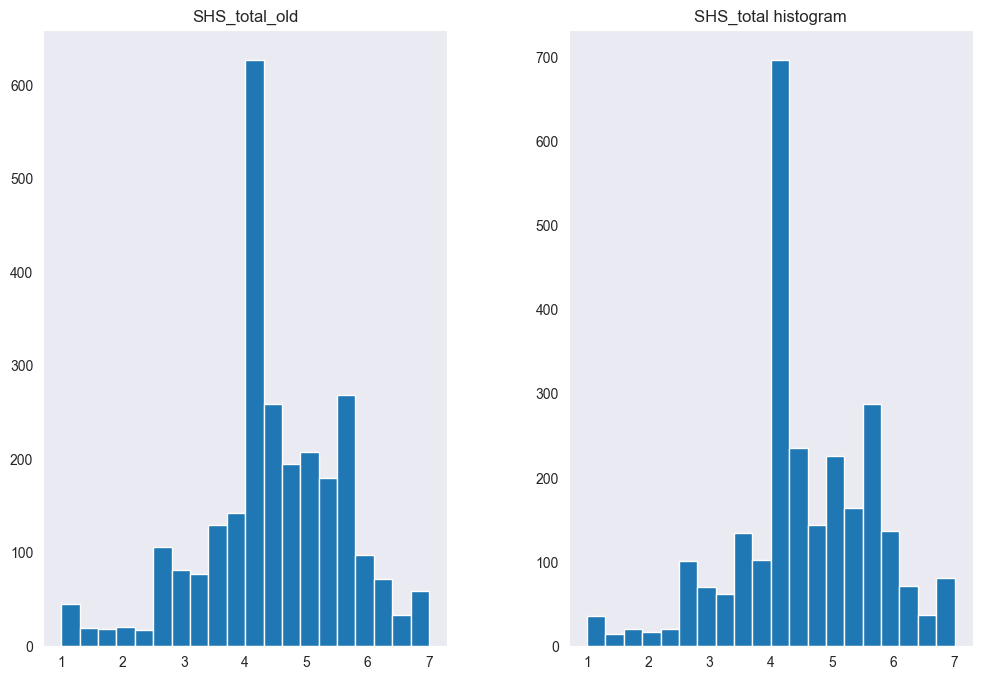

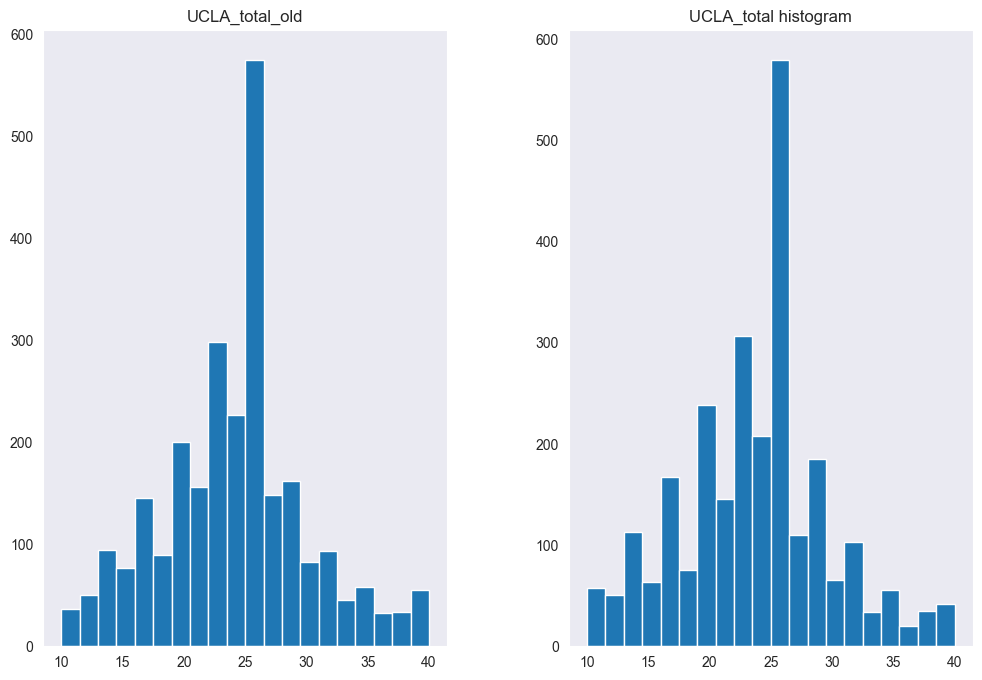

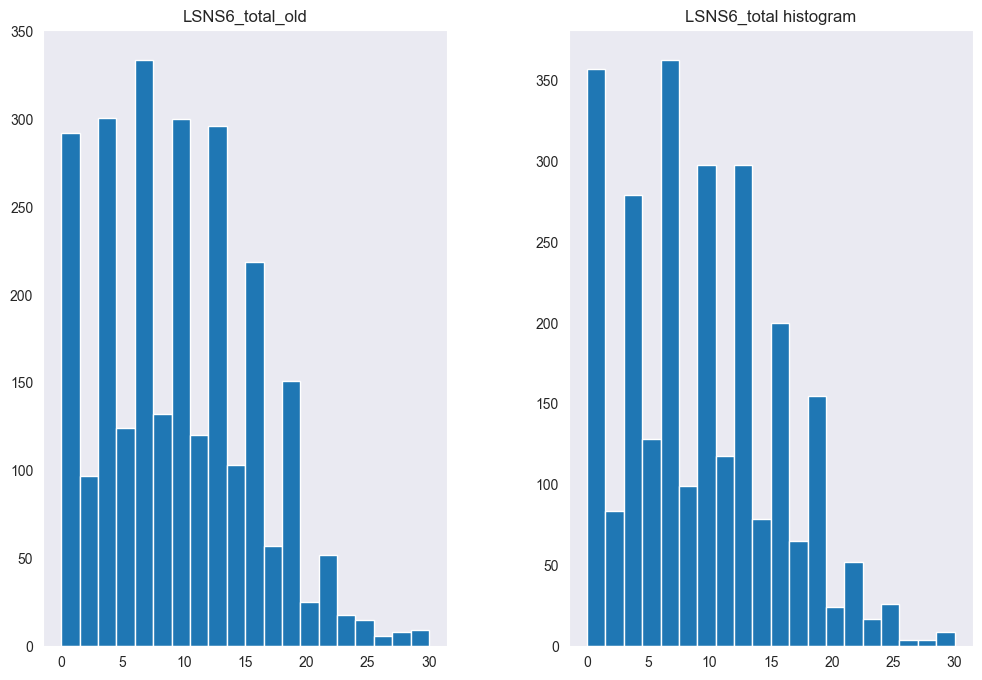

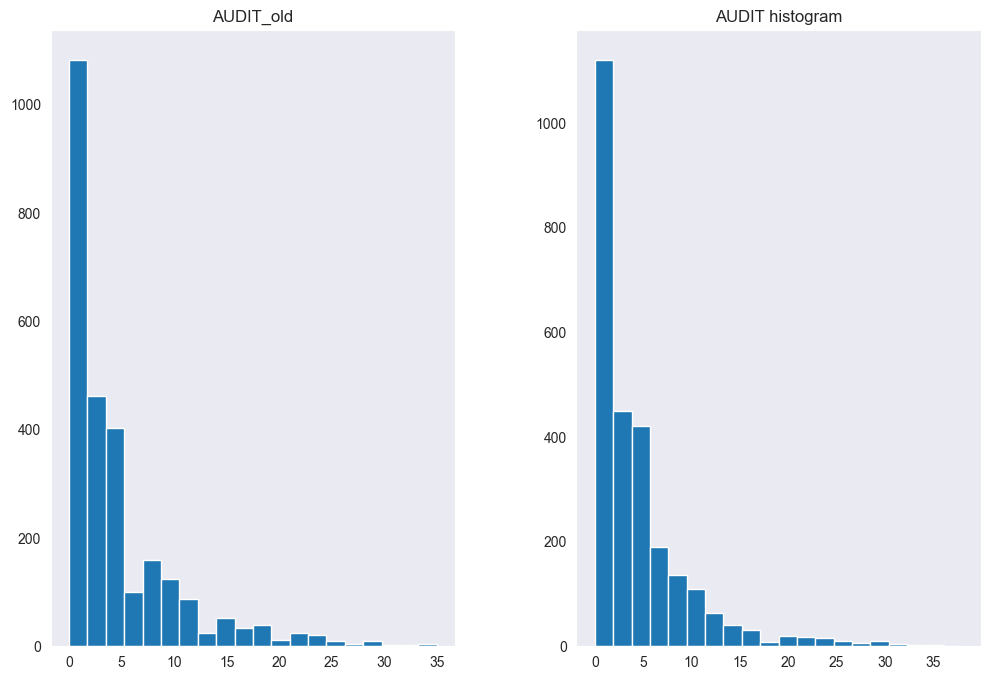

In [15]:
# Histogram
graph_type = 'histogram'
    
for col in column_names:
    col_old = col + '_old'
    col_new = col + '_new'
    
    merged_df[[col_old, col_new]].hist(bins=20, figsize=(12, 8), grid=False)

    plt.title(col + ' ' + graph_type)

    plt.show()
    plt.close()

# Comments
I think the mode is not that informative when it comes to significant differences. Based on the scatterplots, there were still some people with +/- changes.

You could use statistical testing instead (perhaps Wilcoxon signed-rank test, para no normal distribution assumption).
[2:00 pm]
I also suggest using bubble plot instead of scatter plots, since may mga overlapping points, and hindi obvious based on the transparency lang:

https://plotly.com/python/bubble-charts/#:~:text=A%20bubble%20chart%20is%20a,see%20the%20scatter%20plot%20documentation.